In [ ]:
# ============================================================
# SECTION 0: IMPORTS & CONFIGURATION
# ============================================================

import os
import re
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
from itertools import combinations
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

# -------------------- Device & Reproducibility --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = device   # alias for compatibility
print(f"Using device: {device}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -------------------- Hyperparameters --------------------
EMBED_DIM = 128          # dimension for drug mechanism embeddings
LATENT_DIM = 64          # VAE latent dimension
VAE_HIDDEN_DIM = 256
MAX_REGIMEN_LEN = 5      # max number of drugs in a regimen (including SOS/EOS)
LABEL_SMOOTHING = 0.1
KL_ANNEAL_STEPS = 5000
FREE_BITS = 2.0


Using device: cpu


In [ ]:
# ============================================================
# SECTION 1: DATA LOADING & PREPROCESSING (Real Data)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

clinic_df = pd.read_excel(file_path1, engine="openpyxl")
mech_df = pd.read_excel(file_path2, engine="openpyxl")
print(f"Loaded {len(clinic_df)} patients, {len(mech_df)} mechanism entries")

# ---------- Drug name normalization ----------
def normalize_drug_name(name):
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    name = re.sub(r"\([^)]*\)", "", name)
    name = re.sub(r"\s*\+\s*", ", ", name)
    name = re.sub(r"\s*,\s*", ", ", name)
    return name.strip()

def split_combo(combo):
    if not isinstance(combo, str):
        return []
    return [d.strip() for d in combo.split(",") if d.strip()]

def sort_drug_combo(combo):
    if not isinstance(combo, str):
        return ""
    drugs = sorted(split_combo(combo))
    return ", ".join(drugs)

# Normalize clinic drug strings
clinic_df["merged_drugs_norm"] = (
    clinic_df["merged_drugs"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
)

# ---------- Define features ----------
numeric_cols = ['fbs', 'glu', 'hba1c', 'TG', 'cho', 'LDL', 'HDL', 'UA', 'Na', 'K', 'Ca', 'Vit D', 'age']
categorical_cols = ['sex', 'fbs_category', 'tg_category', 'cho_category']

# Drop rows with missing values in these columns
clinic_df = clinic_df.dropna(subset=numeric_cols + categorical_cols).reset_index(drop=True)

from sklearn.model_selection import GroupShuffleSplit

# Groups = unique drug combination strings
groups = clinic_df["merged_drugs_norm"]

# First split: test set (20% of groups)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_val, idx_test = next(gss1.split(clinic_df, groups=groups))

# Second split: validation set (20% of remaining groups → 16% of patients)
groups_train_val = groups.iloc[idx_train_val]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_rel, idx_val_rel = next(gss2.split(clinic_df.iloc[idx_train_val], groups=groups_train_val))

# Convert indices
idx_train = idx_train_val[idx_train_rel]
idx_val = idx_train_val[idx_val_rel]
# idx_test remains as is

# Create dataframes
train_df = clinic_df.iloc[idx_train].copy()
val_df   = clinic_df.iloc[idx_val].copy()
test_df  = clinic_df.iloc[idx_test].copy()

print(f"Leakage‑free splits: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# Sanity check
train_combos = set(clinic_df.iloc[idx_train]["merged_drugs_norm"])
test_combos  = set(clinic_df.iloc[idx_test]["merged_drugs_norm"])
assert len(train_combos & test_combos) == 0, "❌ Leakage detected!"

# ---------- Build drug vocabulary (from training set only) ----------
def build_drug_vocabulary(train_df):
    all_drugs = set()
    for combo in train_df['merged_drugs_norm']:
        all_drugs.update(split_combo(combo))
    drug_to_idx = {drug: i for i, drug in enumerate(sorted(all_drugs))}
    idx_to_drug = {i: drug for drug, i in drug_to_idx.items()}
    return drug_to_idx, idx_to_drug

drug_to_idx, idx_to_drug = build_drug_vocabulary(train_df)
drug_vocab = list(drug_to_idx.keys())
num_drugs = len(drug_vocab)               # number of unique drugs
# Add special tokens: EOS = num_drugs, SOS = num_drugs+1
EOS_TOKEN = num_drugs
SOS_TOKEN = num_drugs + 1
vocab_size = num_drugs + 2                # drugs + EOS + SOS

print(f"Vocabulary size: {vocab_size} (drugs: {num_drugs}, EOS: {EOS_TOKEN}, SOS: {SOS_TOKEN})")

# Function to filter unseen drugs (for val/test)
def filter_to_train_vocab(combo):
    drugs = [d for d in split_combo(combo) if d in drug_to_idx]
    return ", ".join(sorted(drugs))

val_df['merged_drugs_norm'] = val_df['merged_drugs_norm'].apply(filter_to_train_vocab)
test_df['merged_drugs_norm'] = test_df['merged_drugs_norm'].apply(filter_to_train_vocab)

# ---------- Convert regimen to token sequence (with SOS/EOS, fixed length) ----------
def regimen_to_tokens(combo, max_len=MAX_REGIMEN_LEN):
    """Return list of token indices: [SOS, drug1, drug2, ..., EOS, PAD]
       max_len includes SOS and EOS. Pads with EOS if shorter."""
    drug_list = split_combo(combo)
    # Sort drugs to have a deterministic order (important for autoregressive)
    drug_list.sort()
    # Limit number of drugs to max_len-2 (for SOS and EOS)
    drug_list = drug_list[:max_len-2]
    token_ids = [SOS_TOKEN] + [drug_to_idx[d] for d in drug_list] + [EOS_TOKEN]
    # Pad with EOS to reach max_len
    if len(token_ids) < max_len:
        token_ids += [EOS_TOKEN] * (max_len - len(token_ids))
    return token_ids[:max_len]

# Apply to dataframes
train_df['regimen_tokens'] = train_df['merged_drugs_norm'].apply(regimen_to_tokens)
val_df['regimen_tokens']   = val_df['merged_drugs_norm'].apply(regimen_to_tokens)
test_df['regimen_tokens']  = test_df['merged_drugs_norm'].apply(regimen_to_tokens)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 4547 patients, 164 mechanism entries
Vocabulary size: 162 (drugs: 160, EOS: 160, SOS: 161)


In [ ]:
# ============================================================
# SECTION 2: BUILD PATIENT FEATURES (Numerical + Categorical)
# ============================================================

# Scale numerical features
scaler = StandardScaler()
train_num = scaler.fit_transform(train_df[numeric_cols])
val_num   = scaler.transform(val_df[numeric_cols])
test_num  = scaler.transform(test_df[numeric_cols])

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_cat = encoder.fit_transform(train_df[categorical_cols])
val_cat   = encoder.transform(val_df[categorical_cols])
test_cat  = encoder.transform(test_df[categorical_cols])

# Combine
train_features = np.hstack([train_num, train_cat])
val_features   = np.hstack([val_num, val_cat])
test_features  = np.hstack([test_num, test_cat])

PATIENT_FEATURE_DIM = train_features.shape[1]
print(f"Patient feature dimension: {PATIENT_FEATURE_DIM}")

# Convert to torch tensors
train_features = torch.tensor(train_features, dtype=torch.float32)
val_features   = torch.tensor(val_features, dtype=torch.float32)
test_features  = torch.tensor(test_features, dtype=torch.float32)

# Convert regimen tokens to tensors
train_tokens = torch.tensor(np.stack(train_df['regimen_tokens'].values), dtype=torch.long)
val_tokens   = torch.tensor(np.stack(val_df['regimen_tokens'].values), dtype=torch.long)
test_tokens  = torch.tensor(np.stack(test_df['regimen_tokens'].values), dtype=torch.long)

# Create data loaders
batch_size = 64
train_dataset = TensorDataset(train_features, train_tokens)
val_dataset   = TensorDataset(val_features, val_tokens)
test_dataset  = TensorDataset(test_features, test_tokens)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)




Patient feature dimension: 25


In [ ]:
# ============================================================
# SECTION 3: MECHANISM EMBEDDINGS (Optional)
# ============================================================

def build_mechanism_embeddings(train_drugs_set, mech_df):
    """Precompute fixed embeddings for drugs using SentenceTransformer."""
    # Normalize mechanism drug names
    def norm_name(name):
        return str(name).lower().strip().replace("-", " ").replace("_", " ")
    def sort_plus(name):
        drugs = [d.strip() for d in name.split("+")]
        drugs.sort()
        return "+".join(drugs)
    mech_df['Drug Name Norm'] = mech_df['Drug Name'].astype(str).apply(norm_name).apply(sort_plus)
    mech_df = mech_df[mech_df['Drug Name Norm'].isin(train_drugs_set)].copy()
    text_cols = ['Mechanisms', 'Description', 'Target IDs', 'Pathway IDs', 'ATC Code(s)']
    def build_text(row):
        parts = [str(row[col]) for col in text_cols if col in row and pd.notna(row[col])]
        return ' | '.join(parts) if parts else row['Drug Name Norm']
    mech_df['mech_text'] = mech_df.apply(build_text, axis=1)
    model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
    base_dim = model.get_sentence_embedding_dimension()
    projection = nn.Linear(base_dim, EMBED_DIM).to(device)
    embeddings = {}
    with torch.no_grad():
        for _, row in tqdm(mech_df.iterrows(), total=len(mech_df), desc="Drug embeddings"):
            drug = row['Drug Name Norm']
            text = row['mech_text']
            emb = model.encode(text, convert_to_tensor=True, device=device)
            if base_dim != EMBED_DIM:
                emb = projection(emb)
            emb = F.normalize(emb, dim=0)
            embeddings[drug] = emb.cpu()
    default_emb = torch.zeros(EMBED_DIM)
    return {drug: embeddings.get(drug, default_emb.clone()) for drug in train_drugs_set}

# We'll compute embeddings if needed (optional)
train_drugs_set = set(drug_vocab)
drug_embeddings = build_mechanism_embeddings(train_drugs_set, mech_df)
print(f"Computed mechanism embeddings for {len(drug_embeddings)} drugs")

# ============================================================
# SECTION 4: VAE FOR PATIENT LATENT REPRESENTATION
# ============================================================

class PatientVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

    def infer_latent(self, x):
        mu, _ = self.encode(x)
        return mu


# ============================================================
# SECTION 5: MAPCT REGIMEN GENERATOR (Corrected)
# ============================================================

class MAPCTRegimenGenerator(nn.Module):
    def __init__(self, latent_dim, drug_emb_dim, vocab_size, max_len, hidden_dim=256, num_heads=4):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.drug_embeddings = nn.Embedding(vocab_size, drug_emb_dim)
        decoder_layer = nn.TransformerDecoderLayer(d_model=drug_emb_dim, nhead=num_heads,
                                                   dim_feedforward=hidden_dim, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=3)
        self.output_proj = nn.Linear(drug_emb_dim, vocab_size)
        self.latent_proj = nn.Linear(latent_dim, drug_emb_dim)

    def forward(self, z, drug_seq):
        """
        z: (batch, latent_dim)
        drug_seq: (batch, seq_len) token indices (including SOS)
        Returns logits: (batch, seq_len, vocab_size)
        """
        emb = self.drug_embeddings(drug_seq)                # (B, S, D)
        memory = self.latent_proj(z).unsqueeze(1)           # (B, 1, D)
        tgt_mask = torch.triu(torch.ones(drug_seq.size(1), drug_seq.size(1)) * float('-inf'),
                              diagonal=1).to(z.device)
        out = self.decoder(emb, memory, tgt_mask=tgt_mask)  # (B, S, D)
        return self.output_proj(out)                        # (B, S, vocab_size)

    @torch.no_grad()
    def generate(self, z, strategy="greedy", beam_width=5, temperature=1.0):
        """Returns list of lists of token ids (without SOS, includes EOS at end)."""
        batch_size = z.size(0)
        results = []
        for i in range(batch_size):
            z_i = z[i:i+1]
            if strategy == "greedy":
                seq = self._greedy_decode(z_i)
            elif strategy == "beam":
                seq = self._beam_search_decode(z_i, beam_width)
            elif strategy == "stochastic":
                seq = self._stochastic_decode(z_i, temperature)
            else:
                raise ValueError(f"Unknown strategy: {strategy}")
            results.append(seq)
        return results

    def _greedy_decode(self, z):
        seq = []
        for _ in range(self.max_len):
            input_seq = torch.tensor([[SOS_TOKEN] + seq], device=z.device) if seq else torch.tensor([[SOS_TOKEN]], device=z.device)
            logits = self.forward(z, input_seq)               # (1, cur_len, vocab_size)
            next_token = torch.argmax(logits[0, -1], dim=-1).item()
            if next_token == EOS_TOKEN:
                break
            seq.append(next_token)
        return seq

    def _beam_search_decode(self, z, beam_width):
        sequences = [[[], 0.0]]   # (token_list, log_prob)
        for _ in range(self.max_len):
            all_candidates = []
            for tokens, score in sequences:
                input_seq = torch.tensor([[SOS_TOKEN] + tokens], device=z.device)
                logits = self.forward(z, input_seq)          # (1, cur_len, vocab_size)
                log_probs = F.log_softmax(logits[0, -1], dim=-1)  # (vocab_size,)
                top_tokens = torch.topk(log_probs, beam_width).indices
                for tok in top_tokens:
                    new_score = score + log_probs[tok].item()
                    all_candidates.append((tokens + [tok.item()], new_score))
            sequences = sorted(all_candidates, key=lambda x: -x[1])[:beam_width]
            # Stop early if all sequences end with EOS
            if all(seq and seq[-1] == EOS_TOKEN for seq, _ in sequences):
                break
        best_seq = sequences[0][0]
        # Remove trailing EOS? Keep as is.
        return best_seq

    def _stochastic_decode(self, z, temperature):
        seq = []
        for _ in range(self.max_len):
            input_seq = torch.tensor([[SOS_TOKEN] + seq], device=z.device)
            logits = self.forward(z, input_seq)
            probs = F.softmax(logits[0, -1] / temperature, dim=-1)
            next_token = torch.multinomial(probs, 1).item()
            if next_token == EOS_TOKEN:
                break
            seq.append(next_token)
        return seq


# ============================================================
# SECTION 6: CALIBRATION (Temperature Scaling)
# ============================================================

class TemperatureScaling(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature


# ============================================================
# SECTION 7: TRAINING UTILITIES
# ============================================================

def train_vae(model, train_loader, epochs, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    global_step = 0
    losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, _ in train_loader:
            x = x.to(DEVICE)
            recon, mu, logvar = model(x)
            recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
            kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
            kl = torch.max(kl - FREE_BITS, torch.tensor(0.0, device=DEVICE))
            beta = min(1.0, global_step / KL_ANNEAL_STEPS)
            loss = recon_loss + beta * kl
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            global_step += 1
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"VAE Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | KL: {kl.item():.4f} | Beta: {beta:.3f}")
    return losses

def train_generator(generator, vae, train_loader, val_loader, num_epochs, lr=1e-3):
    generator = generator.to(DEVICE)
    for param in generator.parameters():
        param.requires_grad = True
        if param.dtype != torch.float32:
            param.data = param.data.float()
    assert all(p.requires_grad for p in generator.parameters())

    optimizer = torch.optim.Adam(generator.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING, ignore_index=EOS_TOKEN)
    temperature_calib = TemperatureScaling().to(DEVICE)
    calib_optimizer = torch.optim.Adam(temperature_calib.parameters(), lr=0.01)

    gen_losses = []
    temperatures = []

    for epoch in range(num_epochs):
        generator.train()
        total_loss = 0.0
        for patient_feats, regimen_tokens in train_loader:
            patient_feats = patient_feats.to(DEVICE)
            regimen_tokens = regimen_tokens.to(DEVICE)
            with torch.no_grad():
                z = vae.infer_latent(patient_feats)
            logits = generator(z, regimen_tokens)
            loss = criterion(logits[:, :-1, :].reshape(-1, generator.vocab_size),
                             regimen_tokens[:, 1:].reshape(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        gen_losses.append(avg_loss)
        print(f"Generator Epoch {epoch+1}: loss = {avg_loss:.4f}")

        # Calibrate temperature
        generator.eval()
        val_nll = torch.tensor(0.0, device=DEVICE, requires_grad=True)
        val_count = 0
        for patient_feats, regimen_tokens in val_loader:
            patient_feats = patient_feats.to(DEVICE)
            regimen_tokens = regimen_tokens.to(DEVICE)
            with torch.no_grad():
                z = vae.infer_latent(patient_feats)
            logits = generator(z, regimen_tokens)
            calib_logits = temperature_calib(logits)
            nll = F.cross_entropy(calib_logits[:, :-1, :].reshape(-1, generator.vocab_size),
                                  regimen_tokens[:, 1:].reshape(-1), reduction='sum')
            val_nll = val_nll + nll
            val_count += patient_feats.size(0)
        calib_optimizer.zero_grad()
        val_nll = val_nll / val_count
        val_nll.backward()
        calib_optimizer.step()
        temperatures.append(temperature_calib.temperature.item())
        print(f"  Temperature: {temperature_calib.temperature.item():.3f}")

    return gen_losses, temperatures




Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Drug embeddings: 100%|██████████| 108/108 [00:10<00:00, 10.37it/s]


Computed mechanism embeddings for 160 drugs


In [ ]:
# ============================================================
# SECTION 9: VISUALIZATION & ENHANCED INTERACTIVE QUERY
# ============================================================

def plot_training_curves(vae_losses, gen_losses, temperatures):
    """Plot VAE loss, generator loss, and learned temperature."""

    epochs = range(1, len(vae_losses) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # VAE
    axes[0].plot(epochs, vae_losses)
    axes[0].set_title("VAE Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True)

    # Generator
    axes[1].plot(epochs[:len(gen_losses)], gen_losses)
    axes[1].set_title("Generator Training Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True)

    # Temperature
    axes[2].plot(epochs[:len(temperatures)], temperatures, marker='o')
    axes[2].set_title("Temperature Calibration")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Temperature")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


# ============================================================
# LATENT SPACE VISUALIZATION (PCA + t-SNE)
# ============================================================

def visualize_latent_space(vae, dataloader, device, max_samples=500):

    vae.eval()

    all_z = []

    with torch.no_grad():

        for i, (x, _) in enumerate(dataloader):

            if len(all_z) * x.shape[0] >= max_samples:
                break

            x = x.to(device)

            z = vae.infer_latent(x)

            all_z.append(z.cpu())

    all_z = torch.cat(all_z, dim=0).numpy()

    # PCA
    pca = PCA(n_components=2)
    z_pca = pca.fit_transform(all_z)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        random_state=SEED,
        perplexity=min(30, len(all_z)-1)
    )

    z_tsne = tsne.fit_transform(all_z)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(
        z_pca[:, 0],
        z_pca[:, 1],
        alpha=0.7
    )

    axes[0].set_title("PCA Latent Space")

    axes[1].scatter(
        z_tsne[:, 0],
        z_tsne[:, 1],
        alpha=0.7
    )

    axes[1].set_title("t-SNE Latent Space")

    plt.tight_layout()
    plt.show()

    return all_z  # return for potential later use

# ============================================================
# UMAP LATENT SPACE VISUALIZATION (NEW)
# ============================================================

def visualize_latent_space_umap(vae, dataloader, device, max_samples=500):
    try:
        import umap
    except ImportError:
        print("UMAP not installed. Skipping UMAP plot. Install with: !pip install umap-learn")
        return
    vae.eval()
    all_z = []
    with torch.no_grad():
        for i, (x, _) in enumerate(dataloader):
            if len(all_z) * x.shape[0] >= max_samples:
                break
            x = x.to(device)
            z = vae.infer_latent(x)
            all_z.append(z.cpu().numpy())
    all_z = np.vstack(all_z)
    reducer = umap.UMAP(random_state=SEED)
    z_umap = reducer.fit_transform(all_z)
    plt.figure(figsize=(7,6))
    plt.scatter(z_umap[:,0], z_umap[:,1], alpha=0.7)
    plt.title("UMAP Latent Space (VAE)")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.show()


# ============================================================
# DRUG MECHANISM EMBEDDINGS VISUALIZATION (NEW)
# ============================================================

def visualize_drug_mechanism_embeddings(drug_embeddings, drug_vocab, top_n=50):
    """PCA and t‑SNE of precomputed drug mechanism embeddings."""
    drugs = [d for d in drug_vocab if d in drug_embeddings][:top_n]
    if len(drugs) < 2:
        print("Not enough drugs for mechanism visualisation.")
        return
    emb_matrix = torch.stack([drug_embeddings[d] for d in drugs]).numpy()
    # PCA
    pca = PCA(n_components=2)
    emb_pca = pca.fit_transform(emb_matrix)
    # t-SNE
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(drugs)-1))
    emb_tsne = tsne.fit_transform(emb_matrix)
    fig, axes = plt.subplots(1,2,figsize=(16,6))
    axes[0].scatter(emb_pca[:,0], emb_pca[:,1], alpha=0.7)
    axes[0].set_title("PCA of Drug Mechanism Embeddings")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[1].scatter(emb_tsne[:,0], emb_tsne[:,1], alpha=0.7)
    axes[1].set_title("t-SNE of Drug Mechanism Embeddings")
    axes[1].set_xlabel("t-SNE1")
    axes[1].set_ylabel("t-SNE2")
    plt.tight_layout()
    plt.show()




In [ ]:
# ============================================================
# PATIENT LATENT HIGHLIGHT (existing)
# ============================================================

def plot_latent_with_patient(all_z, patient_z, pca, tsne, title_suffix=""):
    """
    all_z: numpy array of latent vectors for all patients (N, latent_dim)
    patient_z: numpy array of latent vector for a single patient (1, latent_dim)
    pca, tsne: fitted PCA and t-SNE objects
    """
    # Transform all points
    z_pca_all = pca.transform(all_z)
    z_tsne_all = tsne.transform(all_z)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ----- PCA plot -----
    axes[0].scatter(z_pca_all[:, 0], z_pca_all[:, 1], alpha=0.5, c='lightblue', s=30, label='All patients')
    if patient_z is not None:
        z_pca_patient = pca.transform(patient_z)
        axes[0].scatter(z_pca_patient[0,0], z_pca_patient[0,1], c='red', s=200, marker='*',
                        edgecolors='black', linewidth=1, label='Selected patient')
        # Force axes to include the patient point
        xlim = axes[0].get_xlim()
        ylim = axes[0].get_ylim()
        axes[0].set_xlim(min(xlim[0], z_pca_patient[0,0]), max(xlim[1], z_pca_patient[0,0]))
        axes[0].set_ylim(min(ylim[0], z_pca_patient[0,1]), max(ylim[1], z_pca_patient[0,1]))
    axes[0].set_title(f'PCA Latent Space{title_suffix}')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].legend()
    axes[0].grid(True)

    # ----- t-SNE plot -----
    axes[1].scatter(z_tsne_all[:, 0], z_tsne_all[:, 1], alpha=0.5, c='lightblue', s=30, label='All patients')
    if patient_z is not None:
        z_tsne_patient = tsne.transform(patient_z)
        axes[1].scatter(z_tsne_patient[0,0], z_tsne_patient[0,1], c='red', s=200, marker='*',
                        edgecolors='black', linewidth=1, label='Selected patient')
        # Force axes to include patient point
        xlim = axes[1].get_xlim()
        ylim = axes[1].get_ylim()
        axes[1].set_xlim(min(xlim[0], z_tsne_patient[0,0]), max(xlim[1], z_tsne_patient[0,0]))
        axes[1].set_ylim(min(ylim[0], z_tsne_patient[0,1]), max(ylim[1], z_tsne_patient[0,1]))
    axes[1].set_title(f't-SNE Latent Space{title_suffix}')
    axes[1].set_xlabel('t-SNE1')
    axes[1].set_ylabel('t-SNE2')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()




In [ ]:
# ============================================================
# DISPLAY REAL PATIENT PROFILE
# ============================================================

def display_real_patient_profile(idx, test_df):

    row = test_df.iloc[idx]

    print("\n" + "="*80)
    print(f"👤 PATIENT #{idx}")
    print("="*80)

    print("\n📋 DEMOGRAPHICS")
    print(f"Age : {row['age']}")
    print(f"Sex : {row['sex']}")

    print("\n🧪 LAB VALUES")

    for col in numeric_cols:
        print(f"{col:<15}: {row[col]}")

    print("\n🏷️ CATEGORIES")

    for col in categorical_cols:
        print(f"{col:<20}: {row[col]}")

    print("\n💊 TRUE REGIMEN")
    print(row['merged_drugs_norm'])

    print("="*80)




In [ ]:
# ============================================================
# TOKEN -> DRUG NAMES
# ============================================================

def tokens_to_drugs(seq):

    drugs = []

    for t in seq:

        if t in (SOS_TOKEN, EOS_TOKEN):
            continue

        if t >= num_drugs:
            continue

        drug = idx_to_drug[t]

        if drug not in drugs:
            drugs.append(drug)

    return drugs


# ============================================================
# BUILD MECHANISM LOOKUP
# ============================================================

def build_mech_lookup(mech_df):

    mech_lookup = {}

    for _, row in mech_df.iterrows():

        drug_name = normalize_drug_name(row['Drug Name'])

        mechanism_parts = []

        for col in [
            'Mechanisms',
            'Description',
            'Target IDs',
            'Pathway IDs'
        ]:

            if col in row and pd.notna(row[col]):
                mechanism_parts.append(str(row[col]))

        mech_lookup[drug_name] = " | ".join(mechanism_parts)

    return mech_lookup


# ============================================================
# GET DRUG PROBABILITIES
# ============================================================

def get_drug_probabilities(generator, z):

    input_seq = torch.tensor([[SOS_TOKEN]], device=DEVICE)

    logits = generator(z, input_seq)

    logits[0, -1, SOS_TOKEN] = -1e9

    probs = F.softmax(logits[0, -1], dim=-1)

    topk = torch.topk(probs[:num_drugs], 10)

    results = []

    for idx_prob, prob in zip(topk.indices, topk.values):

        drug = idx_to_drug[idx_prob.item()]

        results.append((drug, prob.item()))

    return results


# ============================================================
# GENERATE RECOMMENDATIONS
# ============================================================

def generate_recommendation(generator, z, mode):

    if mode == "primary":

        seq = generator.generate(
            z,
            strategy="beam",
            beam_width=5
        )[0]

    elif mode == "alternative":

        seq = generator.generate(
            z,
            strategy="greedy"
        )[0]

    else:

        seq = generator.generate(
            z,
            strategy="stochastic",
            temperature=0.8
        )[0]

    return tokens_to_drugs(seq)




In [ ]:
# ============================================================
# EVALUATION FUNCTION (metrics + diversity)
# ============================================================

def evaluate_mapct_v7(vae, generator, test_loader, idx_to_drug, device,
                      num_stochastic=5, threshold_regimen=0.5):
    """
    Evaluates MAPCT‑v7 on test set.

    Returns:
        dict with keys: precision, recall, f1, accuracy, diversity
    """
    vae.eval()
    generator.eval()

    all_true_multi = []      # list of multi‑hot vectors (list of sets)
    all_pred_multi = []      # list of predicted drug sets (from beam search)
    all_diversity_samples = []  # for diversity: list of generated regimens per patient

    with torch.no_grad():
        for patient_feats, true_tokens in tqdm(test_loader, desc="Evaluating v7"):
            patient_feats = patient_feats.to(device)
            z = vae.infer_latent(patient_feats)           # (batch, latent_dim)

            # --- 1. Primary prediction (beam search) ---
            # generator.generate returns list of token lists (per patient)
            pred_token_lists = generator.generate(z, strategy="beam", beam_width=5)
            for pred_tokens in pred_token_lists:
                pred_drugs = set()
                for t in pred_tokens:
                    if t != SOS_TOKEN and t != EOS_TOKEN and t < len(idx_to_drug):
                        pred_drugs.add(idx_to_drug[t])
                all_pred_multi.append(pred_drugs)

            # --- 2. True drugs (from tokens) ---
            for tokens in true_tokens.cpu().numpy():
                true_drugs = set()
                for t in tokens:
                    if t != SOS_TOKEN and t != EOS_TOKEN and t < len(idx_to_drug):
                        true_drugs.add(idx_to_drug[t])
                all_true_multi.append(true_drugs)

            # --- 3. Collect diversity samples (stochastic) ---
            # Generate multiple regimens per patient
            batch_size = patient_feats.size(0)
            for i in range(batch_size):
                z_i = z[i:i+1]
                patient_samples = []
                for _ in range(num_stochastic):
                    # stochastic generation with temperature 0.8 (or use default)
                    seq = generator.generate(z_i, strategy="stochastic", temperature=0.8)[0]
                    drugs = {idx_to_drug[t] for t in seq if t != SOS_TOKEN and t != EOS_TOKEN and t < len(idx_to_drug)}
                    patient_samples.append(drugs)
                all_diversity_samples.append(patient_samples)

    # ----- Convert true/pred sets to multi‑hot for sklearn metrics -----
    # Build global drug list (all drugs in vocabulary)
    all_drugs = [idx_to_drug[i] for i in range(len(idx_to_drug)) if i not in (SOS_TOKEN, EOS_TOKEN)]
    drug_to_idx_eval = {d: i for i, d in enumerate(all_drugs)}
    num_drugs_eval = len(all_drugs)

    def sets_to_multihot(sets_list):
        mat = np.zeros((len(sets_list), num_drugs_eval), dtype=int)
        for i, drug_set in enumerate(sets_list):
            for d in drug_set:
                if d in drug_to_idx_eval:
                    mat[i, drug_to_idx_eval[d]] = 1
        return mat

    true_mat = sets_to_multihot(all_true_multi)
    pred_mat = sets_to_multihot(all_pred_multi)

    # Micro metrics
    precision = precision_score(true_mat, pred_mat, average='micro', zero_division=0)
    recall    = recall_score(true_mat, pred_mat, average='micro', zero_division=0)
    f1        = f1_score(true_mat, pred_mat, average='micro', zero_division=0)
    accuracy  = accuracy_score(true_mat.flatten(), pred_mat.flatten())

    # ----- Diversity: average pairwise Jaccard distance across stochastic samples -----
    all_jaccard_distances = []
    for patient_samples in all_diversity_samples:
        if len(patient_samples) < 2:
            continue
        jaccard_dists = []
        for (set1, set2) in combinations(patient_samples, 2):
            if len(set1 | set2) == 0:
                dist = 0.0
            else:
                jaccard = len(set1 & set2) / len(set1 | set2)
                dist = 1 - jaccard
            jaccard_dists.append(dist)
        if jaccard_dists:
            all_jaccard_distances.extend(jaccard_dists)
    diversity = np.mean(all_jaccard_distances) if all_jaccard_distances else 0.0

    # ----- Print results -----
    print("\n" + "="*50)
    print("MAPCT‑v7 Test Evaluation")
    print("="*50)
    print(f"Precision (micro): {precision:.4f}")
    print(f"Recall    (micro): {recall:.4f}")
    print(f"F1‑score  (micro): {f1:.4f}")
    print(f"Accuracy (overall): {accuracy:.4f}")
    print(f"Alignment          : N/A (no clinical‑drug latent space)")
    print(f"Generation Diversity (mean pairwise Jaccard distance): {diversity:.4f}")

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'alignment': None,
        'diversity': diversity
    }




=== MAPCT-v7 Hybrid Pipeline ===

[Training VAE]
VAE Epoch 1/20 | Loss: 13.5793 | KL: 34.1922 | Beta: 0.010
VAE Epoch 2/20 | Loss: 7.9005 | KL: 48.2045 | Beta: 0.020
VAE Epoch 3/20 | Loss: 4.6023 | KL: 35.1495 | Beta: 0.030
VAE Epoch 4/20 | Loss: 3.9288 | KL: 30.4289 | Beta: 0.040
VAE Epoch 5/20 | Loss: 3.6994 | KL: 27.2266 | Beta: 0.050
VAE Epoch 6/20 | Loss: 3.7648 | KL: 23.0902 | Beta: 0.060
VAE Epoch 7/20 | Loss: 3.8948 | KL: 19.1576 | Beta: 0.070
VAE Epoch 8/20 | Loss: 3.9280 | KL: 16.7369 | Beta: 0.080
VAE Epoch 9/20 | Loss: 4.0779 | KL: 15.5472 | Beta: 0.090
VAE Epoch 10/20 | Loss: 5.0105 | KL: 17.8332 | Beta: 0.100
VAE Epoch 11/20 | Loss: 4.3851 | KL: 16.0207 | Beta: 0.110
VAE Epoch 12/20 | Loss: 4.2869 | KL: 12.5352 | Beta: 0.120
VAE Epoch 13/20 | Loss: 4.6757 | KL: 34.2462 | Beta: 0.130
VAE Epoch 14/20 | Loss: 4.1593 | KL: 12.1849 | Beta: 0.140
VAE Epoch 15/20 | Loss: 4.2552 | KL: 10.2988 | Beta: 0.150
VAE Epoch 16/20 | Loss: 4.5925 | KL: 11.6517 | Beta: 0.160
VAE Epoch 17/20

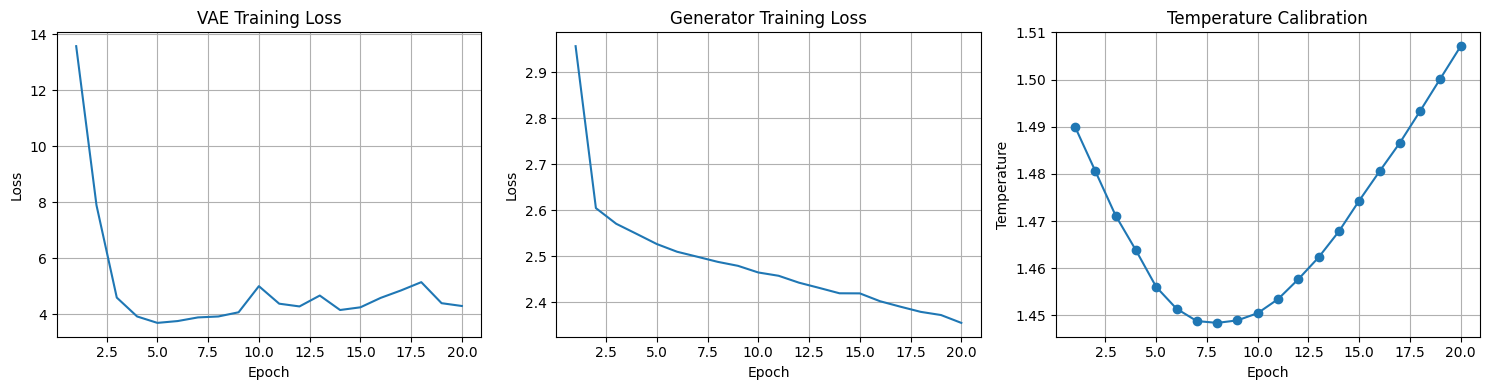

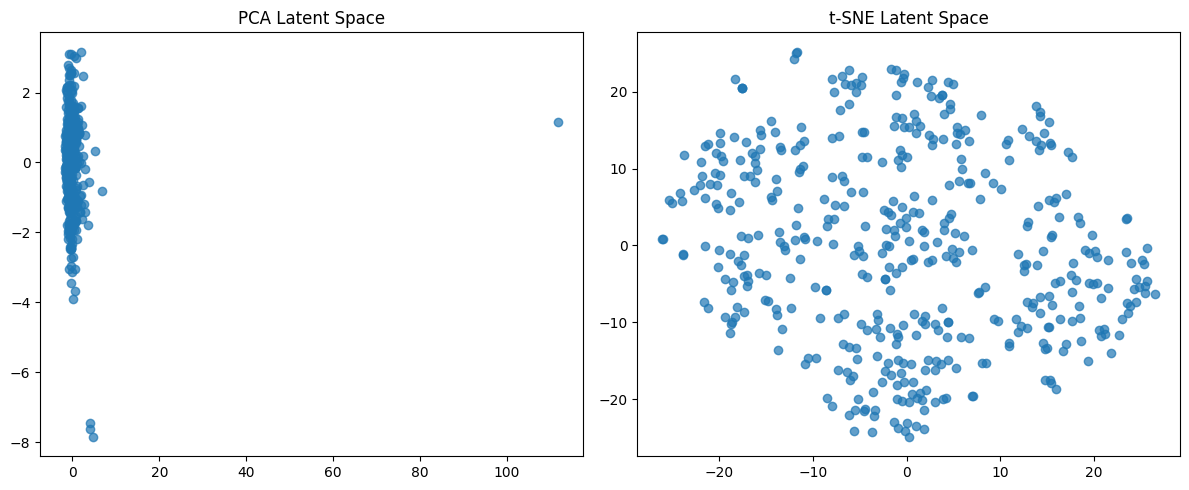

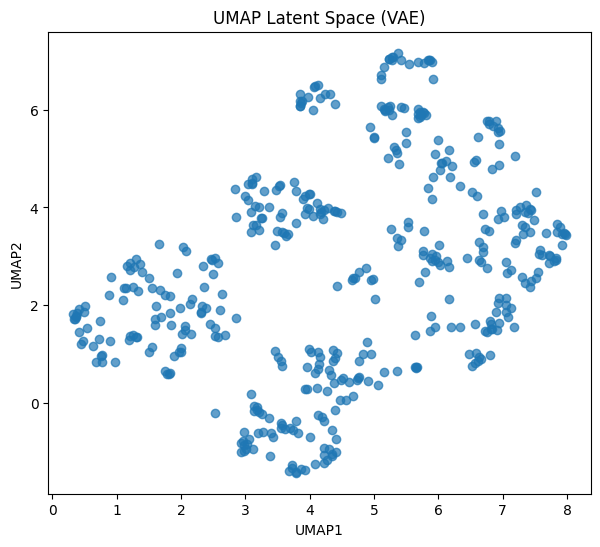

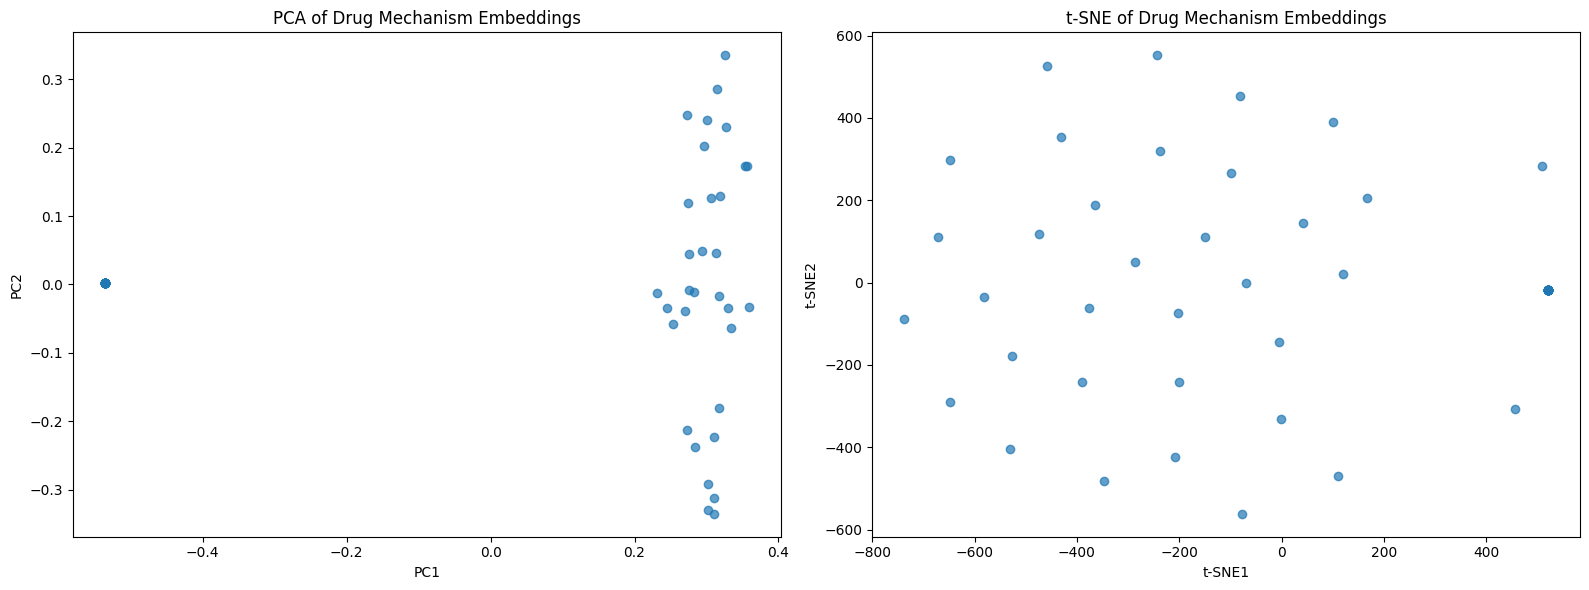

Evaluating v7: 100%|██████████| 15/15 [01:55<00:00,  7.72s/it]



MAPCT‑v7 Test Evaluation
Precision (micro): 0.3006
Recall    (micro): 0.5798
F1‑score  (micro): 0.3959
Accuracy (overall): 0.9745
Alignment          : N/A (no clinical‑drug latent space)
Generation Diversity (mean pairwise Jaccard distance): 0.6540

📊 Test set evaluation results: {'precision': 0.30056804149172633, 'recall': 0.5797999047165316, 'f1': 0.3959011060507482, 'accuracy': 0.9744917582417583, 'alignment': None, 'diversity': np.float64(0.6540105965463109)}
Precomputing latent space for all validation patients...

🩺 CLINICAL DECISION SUPPORT INTERFACE
Enter patient index (0 to 909)
Type 'quit' to exit.


👤 PATIENT #909

📋 DEMOGRAPHICS
Age : 78.0
Sex : 1

🧪 LAB VALUES
fbs            : 143.0
glu            : 221.0
hba1c          : 9.5
TG             : 81.0
cho            : 183.0
LDL            : 103.8
HDL            : 63.0
UA             : 6.233333333333333
Na             : 131.6666666666667
K              : 4.633333333333333
Ca             : 9.5
Vit D          : 38.0
age         

KeyboardInterrupt: Interrupted by user

In [ ]:

# ============================================================
# MAIN FUNCTION (includes evaluation call and new visualisations)
# ============================================================

def main():
    print("=== MAPCT-v7 Hybrid Pipeline ===")

    # ---- Train VAE ----
    vae = PatientVAE(PATIENT_FEATURE_DIM, VAE_HIDDEN_DIM, LATENT_DIM).to(DEVICE)
    print("\n[Training VAE]")
    vae_losses = train_vae(vae, train_loader, epochs=20)

    # ---- Train Regimen Generator ----
    generator = MAPCTRegimenGenerator(LATENT_DIM, EMBED_DIM, vocab_size, MAX_REGIMEN_LEN).to(DEVICE)
    print("\n[Training Regimen Generator]")
    gen_losses, temperatures = train_generator(generator, vae, train_loader, val_loader, num_epochs=20)

    # ---- Visualizations (training curves + latent space) ----
    plot_training_curves(vae_losses, gen_losses, temperatures)
    all_latents_val = visualize_latent_space(vae, val_loader, DEVICE)   # returns all_z for validation
    visualize_latent_space_umap(vae, val_loader, DEVICE)                # UMAP
    visualize_drug_mechanism_embeddings(drug_embeddings, drug_vocab, top_n=50)  # drug mechanism embeddings

    # ---- Evaluate on test set (metrics & diversity) ----
    results_v7 = evaluate_mapct_v7(vae, generator, test_loader, idx_to_drug, DEVICE)
    print("\n📊 Test set evaluation results:", results_v7)

    # ---- Prepare mechanism lookup (for interactive demo) ----
    mech_lookup = build_mech_lookup(mech_df)

    # ---- Precompute latent vectors for all test/val patients (for PCA/t-SNE) ----
    print("Precomputing latent space for all validation patients...")
    vae.eval()
    all_latents = []
    with torch.no_grad():
        for patient_feats, _ in val_loader:
            patient_feats = patient_feats.to(DEVICE)
            z = vae.infer_latent(patient_feats)
            all_latents.append(z.cpu().numpy())
    all_latents = np.concatenate(all_latents, axis=0)  # (N_val, LATENT_DIM)

    # Fit PCA and t-SNE once
    pca = PCA(n_components=2, random_state=SEED)
    pca.fit(all_latents)
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(all_latents)-1))
    tsne.fit(all_latents)  # t-SNE is not incremental, we fit once

    # ---- Interactive query ----
    print("\n" + "="*80)
    print("🩺 CLINICAL DECISION SUPPORT INTERFACE")
    print("="*80)
    print(f"Enter patient index (0 to {len(test_features)-1})")
    print("Type 'quit' to exit.\n")

    while True:
        user_input = input("Patient index: ")
        if user_input.lower() == 'quit':
            break
        try:
            idx = int(user_input)
            if idx < 0 or idx >= len(test_features):
                print(f"❌ Index out of range (0-{len(test_features)-1})")
                continue

            patient = test_features[idx:idx+1].to(DEVICE)
            with torch.no_grad():
                z = vae.infer_latent(patient)           # (1, latent_dim)
                patient_z_np = z.cpu().numpy()
                primary_rec = generate_recommendation(generator, z, "primary")
                alternative_rec = generate_recommendation(generator, z, "alternative")
                exploratory_rec = generate_recommendation(generator, z, "exploratory")
                drug_probs = get_drug_probabilities(generator, z)

            # Display patient profile
            display_real_patient_profile(idx, test_df)

            # Show recommendations
            print("\n🏥 MODEL RECOMMENDATIONS")
            print("="*80)
            print(f"✅ PRIMARY: {', '.join(primary_rec) if primary_rec else 'None'}")
            print(f"🔄 ALTERNATIVE: {', '.join(alternative_rec) if alternative_rec else 'None'}")
            print(f"🧪 EXPLORATORY: {', '.join(exploratory_rec) if exploratory_rec else 'None'}")

            # Show top predicted drugs
            print("\n📊 TOP PREDICTED DRUGS (first step)")
            print("="*80)
            for rank, (drug, prob) in enumerate(drug_probs, 1):
                confidence = prob * 100
                icon = "🟢" if confidence >= 70 else "🟡" if confidence >= 40 else "🔴"
                print(f"{rank:2}. {icon} {drug} ({confidence:.1f}%)")
                mech = mech_lookup.get(drug, "Mechanism unavailable")
                print(f"    {mech[:100]}...")

            # Precision/recall against ground truth
            true_drugs = set(split_combo(test_df.iloc[idx]['merged_drugs_norm']))
            pred_drugs = set(primary_rec)
            correct = true_drugs.intersection(pred_drugs)
            print("\n🎯 PREDICTION ANALYSIS")
            print("="*80)
            print(f"True drugs      : {sorted(true_drugs)}")
            print(f"Predicted drugs : {sorted(pred_drugs)}")
            print(f"Correct matches : {sorted(correct)}")
            precision = len(correct) / max(len(pred_drugs), 1)
            recall = len(correct) / max(len(true_drugs), 1)
            print(f"Precision: {precision:.3f}, Recall: {recall:.3f}")

            print(f"Patient latent shape: {patient_z_np.shape}")
            print(f"Patient latent values (first 5): {patient_z_np[0, :5]}")
            print(f"PCA transform of patient: {pca.transform(patient_z_np)}")
            # ---- Show latent space plot with highlighted patient ----
            plot_latent_with_patient(all_latents, patient_z_np, pca, tsne,
                                     title_suffix=f" - Patient #{idx}")

            # ---- Ask to continue or exit ----
            while True:
                cont = input("\nPress Enter to continue or type 'exit' to quit: ")
                if cont.lower() == 'exit':
                    print("Exiting interactive session.")
                    return
                elif cont == '':
                    break
                else:
                    print("Please press Enter or type 'exit'.")

        except ValueError:
            print("❌ Invalid input. Please enter a number.")
        except Exception as e:
            print(f"❌ Error: {e}")

    print("\n✅ Pipeline finished.")


# ============================================================
# RUN THE PIPELINE
# ============================================================
if __name__ == "__main__":
    main()